# Project 3 Part 2: Transfer Learning with Pretrained CNNs

In this notebook, you will learn how to leverage pretrained CNN models (trained on ImageNet) and fine-tune them for a different image classification task. This demonstrates the power of transfer learning, where knowledge learned from one task can be transferred to another.

## Learning Objectives:
- Understand the concept of transfer learning and when to use it
- Load and use pretrained models from torchvision
- Fine-tune pretrained models on new datasets (Caltech-UCSD Birds)
- Compare training from scratch vs transfer learning
- Explore feature extraction vs fine-tuning strategies

***NOTE:***
When filling in the code, please REMOVE the `pass` and `None` statement.
DO NOT remove the TODO coding highlight in your submission.

### <span style="color: red;"> Grading Criteria for This Notebook (Part 2):</span>
- Code quality and implementation (2 pts)
- Performance benchmarks and analysis (2 pts)
- Analysis and answers to inline questions (2 pts)
- **Total for this notebook: 6 points**

In [12]:
# # Google Colab Setup (Comment out for local computer running)
################################################################################
# Uncomment and set the path to your project folder in Google Drive
################################################################################
# from google.colab import drive
# drive.mount('/content/drive')

# FOLDERNAME = 'cpsc8430/assignments/project3/'
# assert FOLDERNAME is not None, "[!] Enter the foldername."

# import sys
# sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))
# %cd /content/drive/My\ Drive/$FOLDERNAME

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models, datasets

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import seaborn as sns

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

plt.rcParams['figure.figsize'] = (12, 8)

Using device: cpu


## Part 1: Prepare Caltech-101 Dataset

We'll use the **Caltech-101** dataset for this transfer learning task. Caltech-101 contains pictures of objects belonging to 101 categories, with about 40 to 800 images per category.

**Dataset Reference:** [torchvision.datasets.Caltech101](https://pytorch.org/vision/main/generated/torchvision.datasets.Caltech101.html)

The dataset will be automatically downloaded from PyTorch's dataset repository.

Using Caltech-101 Dataset
Dataset source: https://data.caltech.edu/records/mzrjq-6wc02
------------------------------------------------------------
✓ Caltech-101 dataset (object categories) already exists

Loading Caltech-101 with ImageFolder...
✓ Dataset loaded successfully from cpsc8430/datasets/caltech101/caltech-101/101_ObjectCategories!
Total samples in Caltech-101: 9144
Number of categories: 102
------------------------------------------------------------
Dataset: Caltech-101 (loaded with ImageFolder)
Training samples: 7315
Test samples: 1829
Number of classes: 102
Batch size: 32
Image size after transform: 224x224
------------------------------------------------------------
Number of classes: 102


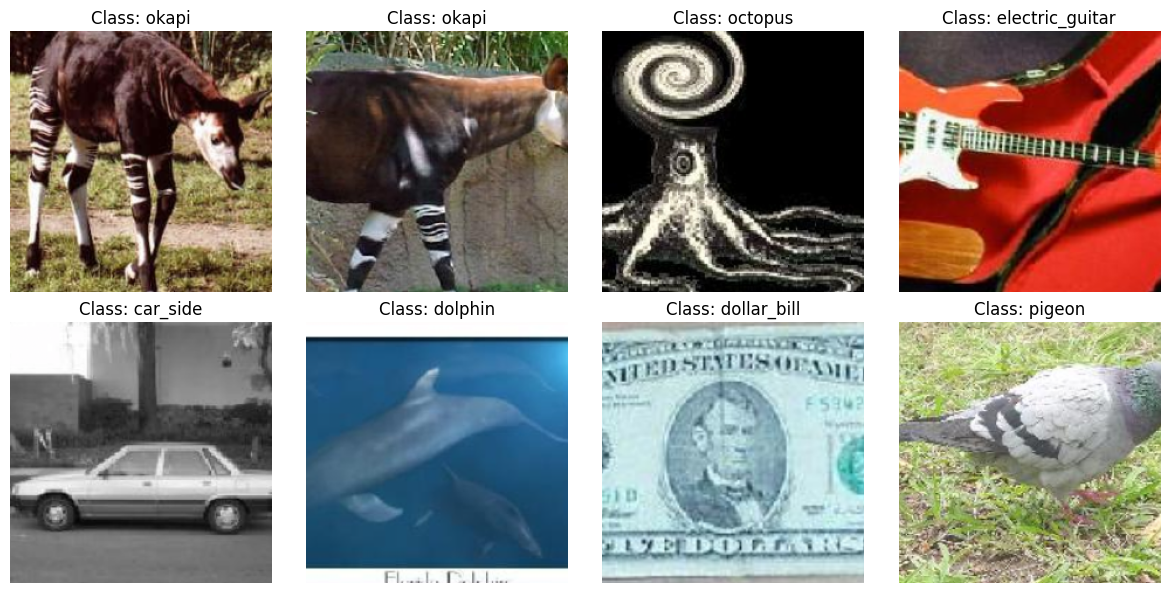

In [13]:
# Use the data_utils module to load the dataset

from cpsc8430.data_utils import load_caltech101,denormalize_standard

# ImageNet statistics for normalization (pretrained models expect these)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Visualize some samples
def denormalize(tensor, mean, std):
    """Denormalize tensor for visualization"""
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

# Load data using the centralized function
train_loader, test_loader, num_classes, class_names = load_caltech101(
    data_root='cpsc8430/datasets',
    batch_size=32,
    num_workers=0, # To work on Mac
    image_size=224,  # For transfer learning (224x224)
    train_split=0.8,
    random_seed=42
)

print(f'Number of classes: {num_classes}')
print(test_loader)

# Visualize some sample Caltech-101 images
# Get a batch from test set
images, labels, text_labels = next(iter(test_loader))

# Visualize
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = images[i].clone()
    img = denormalize(img, imagenet_mean, imagenet_std)
    img = torch.clamp(img, 0, 1)
    ax.imshow(img.permute(1, 2, 0))
    # Use text label for the title
    ax.set_title(f'Class: {text_labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Part 2: Transfer Learning - Feature Extraction

**TODO: Use a pretrained model as a fixed feature extractor**

In feature extraction, we freeze all the convolutional layers and only train the final fully connected layer. This is useful when:
- You have a small dataset
- The new task is similar to the original task (ImageNet classification)
- You want to train quickly

In [14]:
def create_feature_extractor(model_name='resnet18', num_classes=10):
    """
    Create a feature extractor from a pretrained model

    Args:
        model_name: Name of pretrained model ('resnet18', 'resnet50', 'vgg16', etc.)
        num_classes: Number of classes in target dataset

    Returns:
        model: Feature extractor with frozen conv layers
    """
    ################################################################################
    # TODO: Load pretrained model and modify for feature extraction
    # HINT:
    # 1. Load pretrained model using models.<model_name>(pretrained=True)
    #    For newer PyTorch versions, use: models.<model_name>(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # 2. Freeze all parameters: for param in model.parameters(): param.requires_grad = False
    # 3. Replace the final FC layer with a new one for num_classes
    #    For ResNet: model.fc = nn.Linear(model.fc.in_features, num_classes)
    #    For VGG: model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    ################################################################################
    # *****START OF YOUR CODE*****
    model = models.get_model(model_name, weights='DEFAULT')
    for param in model.parameters():
        param.requires_grad = False

    if 'resnet' in model_name:
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    # *****END OF YOUR CODE*****
    ################################################################################

    return model


# Create feature extractor
model_feature_extractor = create_feature_extractor('resnet18', num_classes=num_classes)
model_feature_extractor = model_feature_extractor.to(device)

# Count trainable parameters
trainable_params = sum(p.numel() for p in model_feature_extractor.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_feature_extractor.parameters())

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

Total parameters: 11,228,838
Trainable parameters: 52,326
Frozen parameters: 11,176,512


### Question 1: Feature Extraction

**a) What is the advantage of using a pretrained model as a feature extractor? When is this approach most appropriate?**

$\color{blue}{\textit{Your Answer:}}$

First, it saves a lot of time not having to build your own architecture for this. Second, we also save on computation power and time since these resources were already spent in the creation of it. It is most appropriate to use feature extraction for small datasets since training a new model on a small dataset would have less accuracy.

**b) Why do we freeze the convolutional layers? What would happen if we didn't freeze them?**

$\color{blue}{\textit{Your Answer:}}$

Since all the learning of the shapes that the model was trained on are in the convolutional layers, if we didn't freeze them we would lose some of that learning to new inputs. By unfreezing, we can enact small changes that are specific to our application.

## Part 3: Training Functions

In [18]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=10, device='cpu', scheduler=None):
    """
    Train a model and return history
    """
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False)
        for data, targets, _ in train_pbar:
            data, targets = data.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += targets.size(0)
            train_correct += (predicted == targets).sum().item()

            train_pbar.set_postfix({'loss': loss.item(), 'acc': 100. * train_correct / train_total})

        # Evaluation
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for data, targets, _ in test_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data)
                loss = criterion(outputs, targets)

                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                test_total += targets.size(0)
                test_correct += (predicted == targets).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        train_acc = 100.0 * train_correct / train_total
        test_acc = 100.0 * test_correct / test_total

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(avg_test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% - "
              f"Test Loss: {avg_test_loss:.4f}, Test Acc: {test_acc:.2f}%")

        if scheduler:
            scheduler.step()

    return history


def plot_comparison(histories, labels, title="Model Comparison"):
    """
    Plot comparison of multiple training histories
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    for history, label in zip(histories, labels):
        ax1.plot(history['test_acc'], label=label, marker='o', linewidth=2)
        ax2.plot(history['test_loss'], label=label, marker='o', linewidth=2)

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Test Accuracy (%)')
    ax1.set_title(f'{title} - Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Test Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

## Part 4: Train Feature Extractor

In [19]:
print("="*60)
print("EXPERIMENT 1: FEATURE EXTRACTION (Frozen Conv Layers)")
print("="*60)

################################################################################
# TODO: Train the feature extractor
# HINT: Use a higher learning rate since we're only training the final layer
#       Suggested: lr=0.001 with Adam optimizer
################################################################################
# *****START OF YOUR CODE*****
optimizer_fe = optim.Adam(model_feature_extractor.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

num_epochs_fe = 10
# *****END OF YOUR CODE*****
################################################################################

history_feature_extractor = train_model(
    model_feature_extractor, train_loader, test_loader,
    criterion, optimizer_fe, num_epochs=num_epochs_fe, device=device
)

print(f"\nFinal Test Accuracy (Feature Extraction): {history_feature_extractor['test_acc'][-1]:.2f}%")

EXPERIMENT 1: FEATURE EXTRACTION (Frozen Conv Layers)


Epoch [1/10] - Train Loss: 2.4234, Train Acc: 48.57% - Test Loss: 1.0238, Test Acc: 78.18%


Epoch [2/10] - Train Loss: 1.1218, Train Acc: 73.75% - Test Loss: 0.6414, Test Acc: 83.49%


Epoch [3/10] - Train Loss: 0.8738, Train Acc: 78.24% - Test Loss: 0.5260, Test Acc: 86.17%


Epoch [4/10] - Train Loss: 0.7708, Train Acc: 80.23% - Test Loss: 0.5013, Test Acc: 85.95%


...

Epoch [6/10] - Train Loss: 0.6514, Train Acc: 82.67% - Test Loss: 0.4482, Test Acc: 87.64%


Epoch [7/10] - Train Loss: 0.6087, Train Acc: 83.23% - Test Loss: 0.4482, Test Acc: 87.32%


Epoch [8/10] - Train Loss: 0.5918, Train Acc: 83.27% - Test Loss: 0.4273, Test Acc: 88.14%


Epoch [9/10] - Train Loss: 0.5649, Train Acc: 84.03% - Test Loss: 0.4132, Test Acc: 87.81%


Epoch [10/10] - Train Loss: 0.5678, Train Acc: 84.24% - Test Loss: 0.4197, Test Acc: 87.37%

Final Test Accuracy (Feature Extraction): 87.37%


## Part 5: Fine-tuning - Train All Layers

**TODO: Fine-tune the entire pretrained model**

Fine-tuning involves training all layers of the pretrained model, allowing the convolutional layers to adapt to the new dataset. This typically:
- Achieves better performance than feature extraction
- Requires more training time
- Needs a smaller learning rate to avoid destroying pretrained weights

In [20]:
def create_finetuned_model(model_name='resnet18', num_classes=10):
    """
    Create a model for fine-tuning (all layers trainable)

    Args:
        model_name: Name of pretrained model
        num_classes: Number of classes in target dataset

    Returns:
        model: Model with all layers trainable
    """
    ################################################################################
    # TODO: Load pretrained model for fine-tuning
    # HINT:
    # 1. Load pretrained model (similar to feature extractor)
    # 2. Replace final FC layer for num_classes
    # 3. DO NOT freeze any parameters - all should be trainable
    ################################################################################
    # *****START OF YOUR CODE*****
    model = models.get_model(model_name, weights='DEFAULT')

    if 'resnet' in model_name:
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    # *****END OF YOUR CODE*****
    ################################################################################

    return model


print("="*60)
print("EXPERIMENT 2: FINE-TUNING (All Layers Trainable)")
print("="*60)

model_finetuned = create_finetuned_model('resnet18', num_classes=num_classes)
model_finetuned = model_finetuned.to(device)

trainable_params = sum(p.numel() for p in model_finetuned.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

################################################################################
# TODO: Set up optimizer for fine-tuning
# HINT: Use a SMALLER learning rate than feature extraction (e.g., lr=0.0001)
#       This prevents destroying the pretrained weights
################################################################################
# *****START OF YOUR CODE*****
optimizer_ft = optim.Adam(model_finetuned.parameters(), lr=0.0001)
num_epochs_ft = 15
# *****END OF YOUR CODE*****
################################################################################

history_finetuned = train_model(
    model_finetuned, train_loader, test_loader,
    criterion, optimizer_ft, num_epochs=num_epochs_ft, device=device
)

print(f"\nFinal Test Accuracy (Fine-tuning): {history_finetuned['test_acc'][-1]:.2f}%")

EXPERIMENT 2: FINE-TUNING (All Layers Trainable)
Trainable parameters: 11,228,838


Epoch [1/15] - Train Loss: 2.2092, Train Acc: 53.18% - Test Loss: 0.8762, Test Acc: 79.66%


Epoch [2/15] - Train Loss: 1.0428, Train Acc: 77.24% - Test Loss: 0.5548, Test Acc: 86.44%


Epoch [3/15] - Train Loss: 0.7615, Train Acc: 82.87% - Test Loss: 0.4441, Test Acc: 87.97%


Epoch [4/15] - Train Loss: 0.6075, Train Acc: 85.78% - Test Loss: 0.3467, Test Acc: 92.02%


...

Epoch [11/15] - Train Loss: 0.3424, Train Acc: 90.94% - Test Loss: 0.3261, Test Acc: 91.36%


Epoch [12/15] - Train Loss: 0.3440, Train Acc: 91.17% - Test Loss: 0.3105, Test Acc: 90.92%


Epoch [13/15] - Train Loss: 0.3293, Train Acc: 91.43% - Test Loss: 0.3704, Test Acc: 88.57%


Epoch [14/15] - Train Loss: 0.3050, Train Acc: 92.37% - Test Loss: 0.3717, Test Acc: 89.07%


Epoch [15/15] - Train Loss: 0.3038, Train Acc: 92.33% - Test Loss: 0.3958, Test Acc: 88.30%

Final Test Accuracy (Fine-tuning): 88.30%


## Part 6: Training from Scratch (for Comparison)

**TODO: Train a model from scratch (random initialization) for comparison**

In [22]:
print("="*60)
print("EXPERIMENT 3: TRAINING FROM SCRATCH (No Pretrained Weights)")
print("="*60)

################################################################################
# TODO: Create model from scratch (no pretrained weights)
# HINT: Use models.resnet18(pretrained=False) or models.resnet18(weights=None)
#       Then replace the final FC layer
################################################################################
# *****START OF YOUR CODE*****
model_scratch = models.resnet18(pretrained=False)
model_scratch.fc = nn.Linear(model_scratch.fc.in_features, num_classes)
# *****END OF YOUR CODE*****
################################################################################

model_scratch = model_scratch.to(device)

optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)
num_epochs_scratch = 15

history_scratch = train_model(
    model_scratch, train_loader, test_loader,
    criterion, optimizer_scratch, num_epochs=num_epochs_scratch, device=device
)

print(f"\nFinal Test Accuracy (From Scratch): {history_scratch['test_acc'][-1]:.2f}%")

EXPERIMENT 3: TRAINING FROM SCRATCH (No Pretrained Weights)


/Users/stevenzinn/Desktop/Deep Learning/Project3/vpy/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/stevenzinn/Desktop/Deep Learning/Project3/vpy/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
                                                                                                                                                                                                   

Epoch [1/15] - Train Loss: 3.8929, Train Acc: 20.51% - Test Loss: 3.4952, Test Acc: 24.22%


Epoch [2/15] - Train Loss: 3.4826, Train Acc: 25.48% - Test Loss: 3.1875, Test Acc: 28.49%


Epoch [3/15] - Train Loss: 3.2540, Train Acc: 27.31% - Test Loss: 2.9505, Test Acc: 31.49%


...

Epoch [11/15] - Train Loss: 2.1473, Train Acc: 46.84% - Test Loss: 1.8537, Test Acc: 52.38%


Epoch [12/15] - Train Loss: 2.0339, Train Acc: 49.00% - Test Loss: 1.7247, Test Acc: 54.35%


Epoch [13/15] - Train Loss: 1.9379, Train Acc: 51.31% - Test Loss: 1.7641, Test Acc: 54.24%


Epoch [14/15] - Train Loss: 1.8772, Train Acc: 52.36% - Test Loss: 1.6507, Test Acc: 56.97%


Epoch [15/15] - Train Loss: 1.8018, Train Acc: 54.35% - Test Loss: 1.5704, Test Acc: 60.36%

Final Test Accuracy (From Scratch): 60.36%


## Part 7: Compare All Approaches

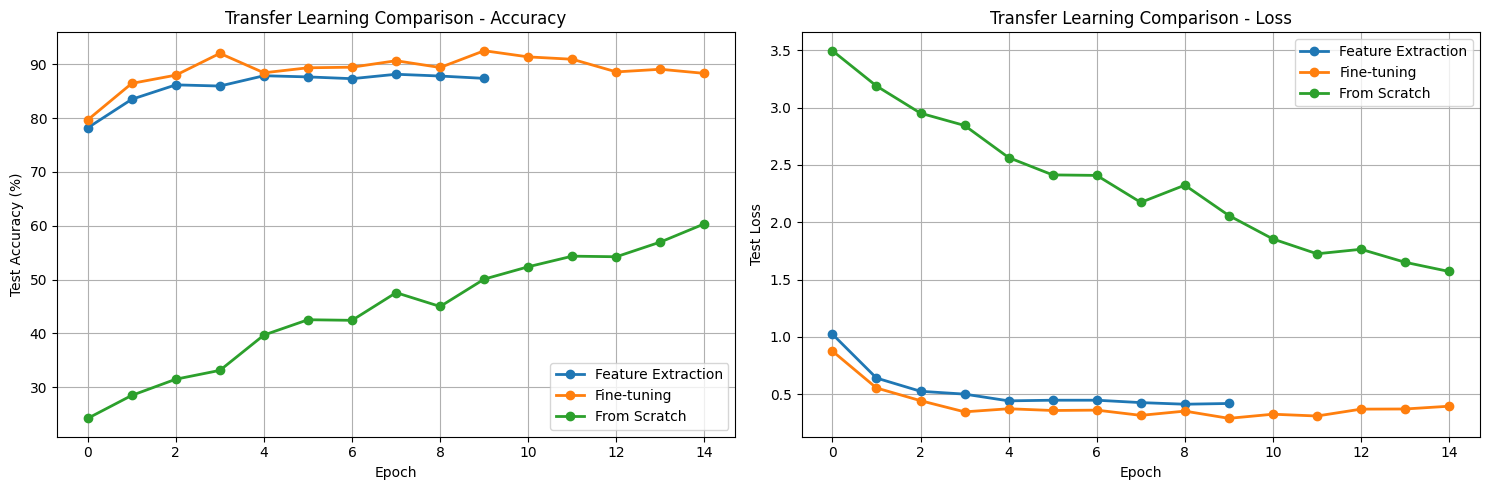


FINAL COMPARISON SUMMARY
Feature Extraction: 87.37%
Fine-tuning: 88.30%
From Scratch: 60.36%

Best approach:  Fine-tuning

Improvement (Feature Extraction vs Scratch): +27.01%
Improvement (Fine-tuning vs Scratch): +27.94%


In [23]:
# Compare all three approaches
histories = [history_feature_extractor, history_finetuned, history_scratch]
labels = ['Feature Extraction', 'Fine-tuning', 'From Scratch']

plot_comparison(histories, labels, "Transfer Learning Comparison")

# Print summary
print("\n" + "="*60)
print("FINAL COMPARISON SUMMARY")
print("="*60)
print(f"Feature Extraction: {history_feature_extractor['test_acc'][-1]:.2f}%")
print(f"Fine-tuning: {history_finetuned['test_acc'][-1]:.2f}%")
print(f"From Scratch: {history_scratch['test_acc'][-1]:.2f}%")
print("\nBest approach: ", labels[np.argmax([h['test_acc'][-1] for h in histories])])

# Calculate improvement
improvement_fe_vs_scratch = history_feature_extractor['test_acc'][-1] - history_scratch['test_acc'][-1]
improvement_ft_vs_scratch = history_finetuned['test_acc'][-1] - history_scratch['test_acc'][-1]

print(f"\nImprovement (Feature Extraction vs Scratch): {improvement_fe_vs_scratch:+.2f}%")
print(f"Improvement (Fine-tuning vs Scratch): {improvement_ft_vs_scratch:+.2f}%")

### Question 2: Transfer Learning Comparison

**a) Compare the three approaches (feature extraction, fine-tuning, from scratch). Which performed best? Why?**

$\color{blue}{\textit{Your Answer:}}$

The fine-tuning approach performed the best since it was able to use the pretrained model's layers and build off of it. The weights were changed as they were adjusted slightly.

**b) How does the dataset size affect the choice between these approaches? When would you choose feature extraction vs fine-tuning?**

$\color{blue}{\textit{Your Answer:}}$

For small datasets that have even moderate similarities to the dataset the model was trained on, just using feature extraction makes sense. But for larger, more specific dataset, unfreezing the layers for fine-tuning will increase it's performance.

**c) Why did we use a smaller learning rate for fine-tuning compared to feature extraction?**

$\color{blue}{\textit{Your Answer:}}$

Feature extraction is training the classifier, whose parameters are set mostly at random. A faster lr makes a lot of sense for quicker learning. But fine-tuning uses the model's convolutional layers to train on, which are already trained too. So, to enact small changes to not unadapt the model it is best to have a very low lr.

## Part 8: Advanced Fine-tuning - Differential Learning Rates

**TODO: Implement differential learning rates for different layers**

A more sophisticated approach is to use different learning rates for different parts of the network:
- Lower learning rate for early layers (close to ImageNet features)
- Higher learning rate for later layers (task-specific features)
- Highest learning rate for the final classification layer

EXPERIMENT 4: FINE-TUNING WITH DIFFERENTIAL LEARNING RATES


Epoch [1/15] - Train Loss: 1.7129, Train Acc: 61.60% - Test Loss: 0.5011, Test Acc: 86.39%


Epoch [2/15] - Train Loss: 0.7087, Train Acc: 80.75% - Test Loss: 0.3828, Test Acc: 88.19%


Epoch [3/15] - Train Loss: 0.5669, Train Acc: 84.24% - Test Loss: 0.3332, Test Acc: 90.05%


Epoch [4/15] - Train Loss: 0.4839, Train Acc: 86.45% - Test Loss: 0.4123, Test Acc: 87.64%


...

Epoch [11/15] - Train Loss: 0.3267, Train Acc: 90.54% - Test Loss: 0.3974, Test Acc: 87.97%


Epoch [12/15] - Train Loss: 0.3333, Train Acc: 90.29% - Test Loss: 0.5340, Test Acc: 86.39%


Epoch [13/15] - Train Loss: 0.3132, Train Acc: 91.16% - Test Loss: 0.3988, Test Acc: 89.07%


Epoch [14/15] - Train Loss: 0.3100, Train Acc: 91.13% - Test Loss: 0.4359, Test Acc: 87.64%


Epoch [15/15] - Train Loss: 0.2904, Train Acc: 91.52% - Test Loss: 0.4657, Test Acc: 87.42%

Final Test Accuracy (Differential LR): 87.42%


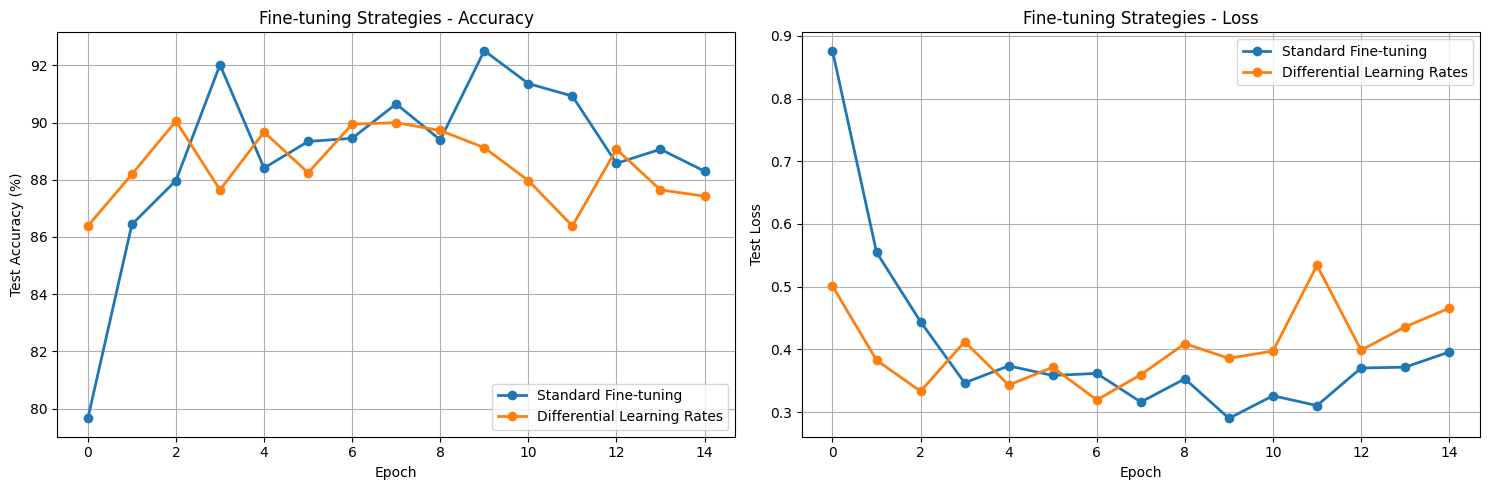

In [26]:
print("="*60)
print("EXPERIMENT 4: FINE-TUNING WITH DIFFERENTIAL LEARNING RATES")
print("="*60)

model_diff_lr = create_finetuned_model('resnet18', num_classes=num_classes)
model_diff_lr = model_diff_lr.to(device)

################################################################################
# TODO: Set up optimizer with differential learning rates
# HINT: Create parameter groups with different learning rates
# Example structure:
# optimizer = optim.Adam([
#     {'params': early_layers.parameters(), 'lr': 1e-5},
#     {'params': middle_layers.parameters(), 'lr': 1e-4},
#     {'params': final_layer.parameters(), 'lr': 1e-3}
# ])
################################################################################
# *****START OF YOUR CODE*****
early_layers = nn.Sequential(
    model_diff_lr.conv1, 
    model_diff_lr.bn1, 
    model_diff_lr.layer1, 
    model_diff_lr.layer2
)
middle_layers = nn.Sequential(
    model_diff_lr.layer3, 
    model_diff_lr.layer4
)
final_layers = model_diff_lr.fc
optimizer_diff_lr = optim.AdamW([
    {'params': early_layers.parameters(), 'lr': 1e-5, 'weight_decay': 1e-3},
    {'params': middle_layers.parameters(), 'lr': 1e-4, 'weight_decay': 1e-3},
    {'params': final_layers.parameters(), 'lr': 1e-3, 'weight_decay': 1e-4},
])
# *****END OF YOUR CODE*****
################################################################################

num_epochs_diff_lr = 15

history_diff_lr = train_model(
    model_diff_lr, train_loader, test_loader,
    criterion, optimizer_diff_lr, num_epochs=num_epochs_diff_lr, device=device
)

print(f"\nFinal Test Accuracy (Differential LR): {history_diff_lr['test_acc'][-1]:.2f}%")

# Compare with standard fine-tuning
plot_comparison(
    [history_finetuned, history_diff_lr],
    ['Standard Fine-tuning', 'Differential Learning Rates'],
    "Fine-tuning Strategies"
)

### Question 3: Advanced Fine-tuning

**a) Explain the intuition behind using differential learning rates. Why might this be better than using a single learning rate?**

$\color{blue}{\textit{Your Answer:}}$

The earlier layers are specialized to specific features (lines, curves, etc), while the final layers are more specific to the current training. As you move up the layers, the lr should become larger to account for less inherent complexity.

**b) In your experiments, did differential learning rates improve performance? Why or why not?**

$\color{blue}{\textit{Your Answer:}}$

It did not, and I am not exactly sure why.

## Part 9: Visualize Learned Features

Let's visualize what the pretrained model has learned by looking at the activation maps.

Original Test Image:


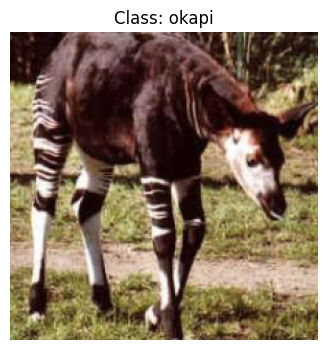

Early layer features:


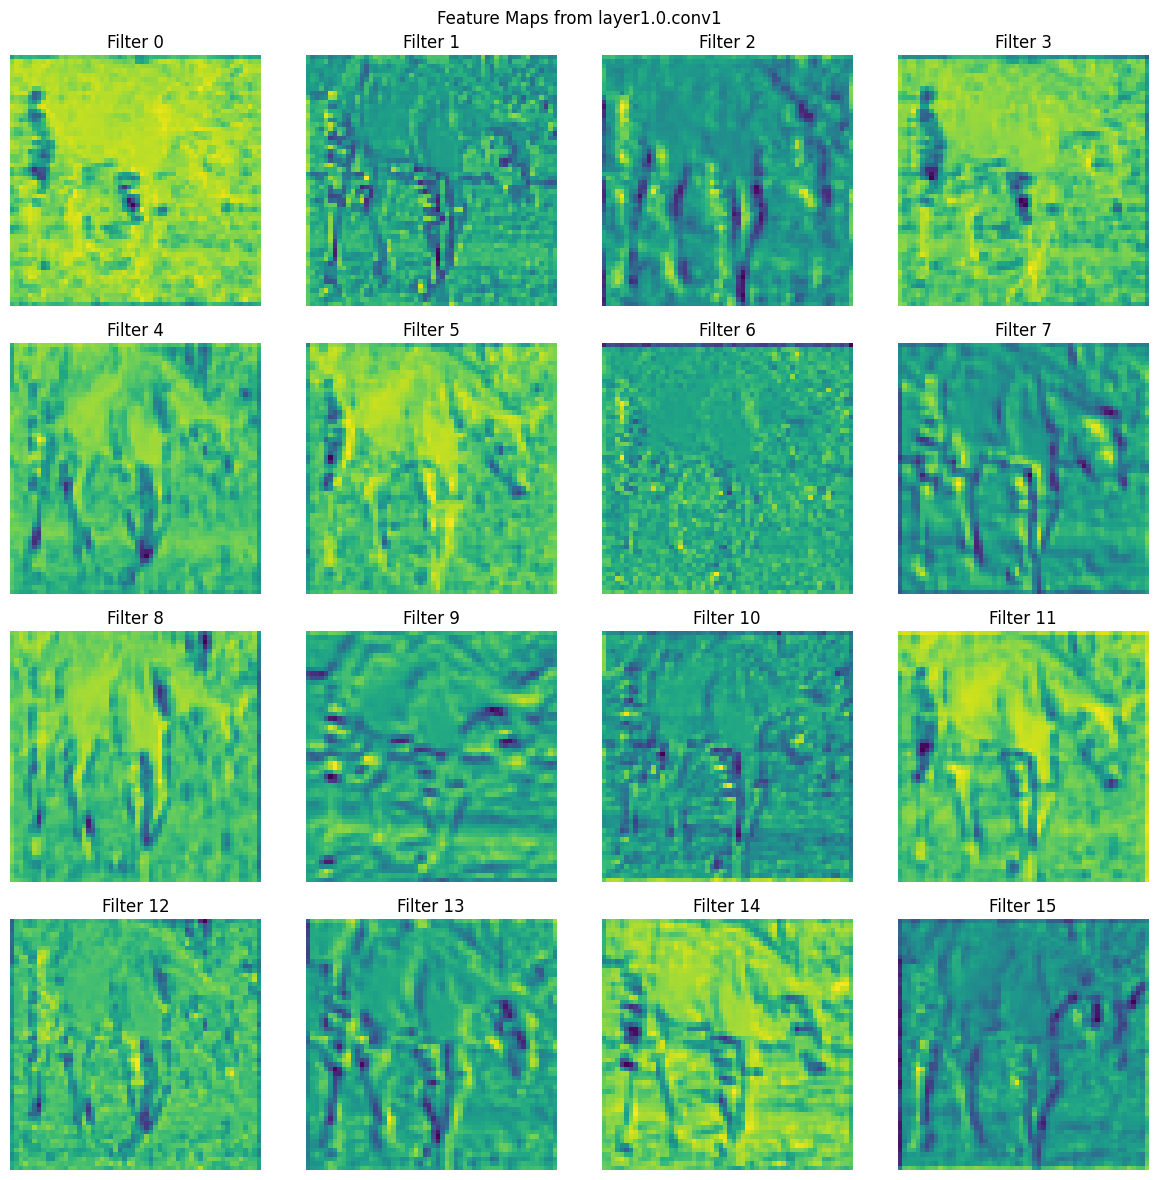


Deep layer features:


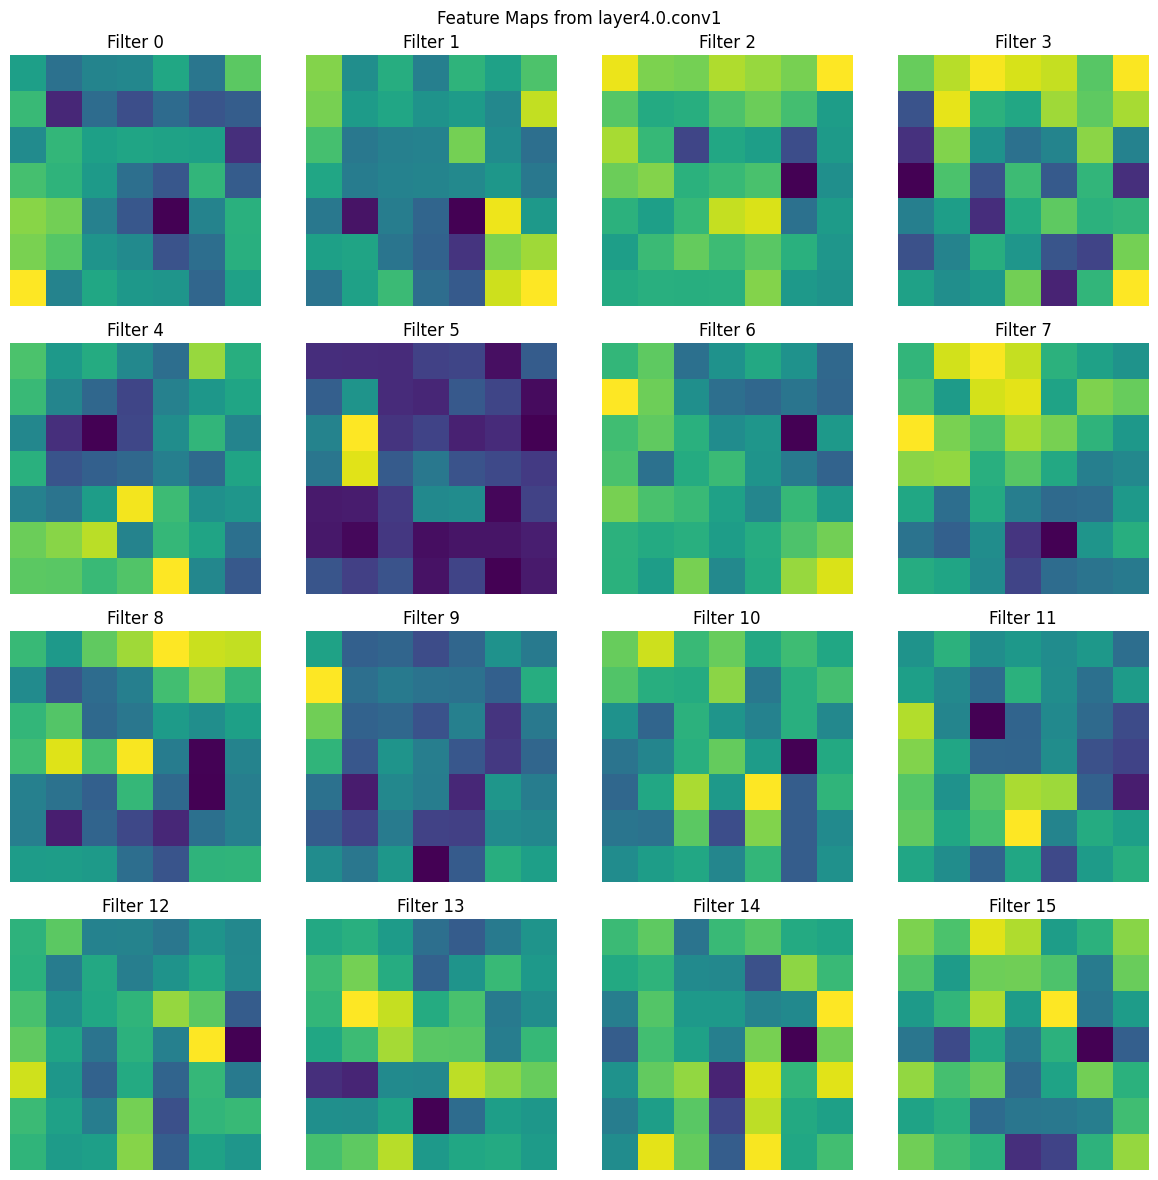

In [27]:
def visualize_feature_maps(model, image, layer_name, device='cpu', num_filters=16):
    """
    Visualize feature maps from a specific layer
    """
    model.eval()

    # Register hook to capture activations
    activations = []
    def hook_fn(module, input, output):
        activations.append(output)

    # Get the layer
    layer = dict(model.named_modules())[layer_name]
    handle = layer.register_forward_hook(hook_fn)

    # Forward pass
    image = image.unsqueeze(0).to(device)
    with torch.no_grad():
        _ = model(image)

    handle.remove()

    # Get activations
    activation = activations[0].squeeze(0).cpu()

    # Plot
    num_filters = min(num_filters, activation.shape[0])
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    for i, ax in enumerate(axes.flat):
        if i < num_filters:
            ax.imshow(activation[i], cmap='viridis')
            ax.set_title(f'Filter {i}')
        ax.axis('off')
    plt.suptitle(f'Feature Maps from {layer_name}')
    plt.tight_layout()
    plt.show()

# Get a test image and its label
test_dataset = test_loader.dataset
test_image, _, test_text_label = test_dataset[0]

# Visualize the original image
print("Original Test Image:")
plt.figure(figsize=(4, 4))
# Denormalize and permute for visualization
img_display = test_image.clone().cpu()
img_display = denormalize(img_display, imagenet_mean, imagenet_std)
img_display = torch.clamp(img_display, 0, 1)
plt.imshow(img_display.permute(1, 2, 0))
plt.title(f'Class: {test_text_label}')
plt.axis('off')
plt.show()


# Visualize features from different layers
print("Early layer features:")
visualize_feature_maps(model_finetuned, test_image, 'layer1.0.conv1', device=device)

print("\nDeep layer features:")
visualize_feature_maps(model_finetuned, test_image, 'layer4.0.conv1', device=device)

### Question 4: Feature Visualization

**a) Compare the feature maps from early layers vs deep layers. What differences do you observe?**

$\color{blue}{\textit{Your Answer:}}$

Early layers have the shapes (lines and curves) figured out while the final layers seems to be clustering features?

**b) How do these visualizations help you understand what the network has learned?**

$\color{blue}{\textit{Your Answer:}}$

They demonstrate the layers are working as expected.